# ABL Bio's Current Patent Portfolio (as of Feb 26, 2026)
Look into patent's ABL Bio owns using Lens.org
- Use search term "ABL BIO INC KR", "ABL BIO INC", "ABL BIO", "ABL BIO INCORPORATED" as owner or applicant name
- For applicant -> Results will show 466 Patent Records (Expand by Simple Family), but after selecting simple families, there are 37 results
- For owner -> Results will show 437 Patent Records (Expand by Simple Family), but 24 Simple families
- But if you look at Owner section of those applicant sections, you'll see it is because they are NaN
- So just Lens convention, where the owner is the applicant
- There is also no patent simple families that ABL is the owner of but not the applicant -> suggests currently no acquisition-based portfolio growth

 So ABL Bio has original 37 simple families ("inventions")


In [5]:
import pandas as pd

own_abl = pd.read_csv("../data/raw/abl-37.csv")

print(own_abl.shape)

(37, 37)


In [6]:
print(own_abl.columns)

Index(['#', 'Jurisdiction', 'Kind', 'Display Key', 'Lens ID',
       'Publication Date', 'Publication Year', 'Application Number',
       'Application Date', 'Priority Numbers', 'Earliest Priority Date',
       'Title', 'Abstract', 'Applicants', 'Inventors', 'Owners', 'URL',
       'Document Type', 'Has Full Text', 'Cites Patent Count',
       'Cited by Patent Count', 'Simple Family Size', 'Simple Family Members',
       'Simple Family Member Jurisdictions', 'Extended Family Size',
       'Extended Family Members', 'Extended Family Member Jurisdictions',
       'Sequence Count', 'CPC Classifications', 'IPCR Classifications',
       'US Classifications', 'NPL Citation Count',
       'NPL Resolved Citation Count', 'NPL Resolved Lens ID(s)',
       'NPL Resolved External ID(s)', 'NPL Citations', 'Legal Status'],
      dtype='object')


## Timeline of Earliest Priority Date

In [136]:
own_abl['Earliest Priority Date'] = pd.to_datetime(own_abl['Earliest Priority Date'])
own_abl['Year'] = own_abl['Earliest Priority Date'].dt.year

In [139]:
own_abl['Legal Status'].value_counts(dropna=False)

Legal Status
PENDING         22
ACTIVE          12
DISCONTINUED     3
Name: count, dtype: int64

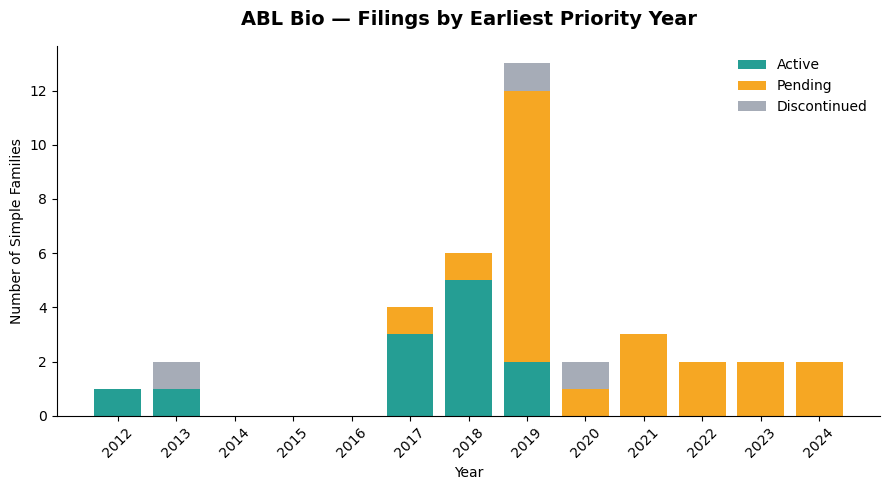

In [140]:
import matplotlib.pyplot as plt

# Convert dates
own_abl['Earliest Priority Date'] = pd.to_datetime(own_abl['Earliest Priority Date'])
own_abl['Year'] = own_abl['Earliest Priority Date'].dt.year

# Group properly (include all statuses)
status_yearly = (
    own_abl.groupby(['Year', 'Legal Status'])
    .size()
    .unstack(fill_value=0)
)

all_years = range(own_abl['Year'].min(), own_abl['Year'].max() + 1)
status_yearly = status_yearly.reindex(all_years, fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

bottom_vals = 0

colors = {
    'ACTIVE': '#0D9488',        # teal
    'PENDING': '#F59E0B',       # amber
    'DISCONTINUED': '#9CA3AF'   # grey
}

for status in ['ACTIVE', 'PENDING', 'DISCONTINUED']:
    vals = status_yearly.get(status, 0)
    ax.bar(
        all_years,
        vals,
        bottom=bottom_vals,
        label=status.title(),
        color=colors[status],
        alpha=0.9
    )
    bottom_vals = bottom_vals + vals

ax.set_title("ABL Bio — Filings by Earliest Priority Year",
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Simple Families")
ax.set_xticks(all_years)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [145]:
print("Total families:", len(own_abl))
print("Stacked total:", status_yearly.sum().sum())

Total families: 37
Stacked total: 37


## Legal Status

In [146]:
status_counts = own_abl['Legal Status'].value_counts()

status_summary = pd.DataFrame({
    'Count': status_counts,
    'Percent': round(status_counts / len(own_abl) * 100, 1)
})

status_summary

,Count,Percent
Legal Status,,
PENDING,22,59.5
ACTIVE,12,32.4
DISCONTINUED,3,8.1


In [147]:
print(f"Total rows: {len(own_abl)}")
print(f"Unique families: {own_abl['Simple Family Members'].nunique()}")

print("\nOverall Legal Status Distribution:")
print(own_abl['Legal Status'].value_counts())

print("\nLegal Status Per Family:")
print(
    own_abl
    .groupby('Simple Family Members')['Legal Status']
    .value_counts()
)

Total rows: 37
Unique families: 37

Overall Legal Status Distribution:
Legal Status
PENDING         22
ACTIVE          12
DISCONTINUED     3
Name: count, dtype: int64

Legal Status Per Family:
Simple Family Members                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## Jurisdiction

In [148]:
#Jurisdiction Coverage in Major Markets
own_abl['has_us'] = own_abl['Extended Family Member Jurisdictions'].str.contains('US', na=False) #USA
own_abl['has_ep'] = own_abl['Extended Family Member Jurisdictions'].str.contains('EP', na=False) #Europe
own_abl['has_cn'] = own_abl['Extended Family Member Jurisdictions'].str.contains('CN', na=False) #China
own_abl['has_jp'] = own_abl['Extended Family Member Jurisdictions'].str.contains('JP', na=False) #Japan
own_abl['has_wo'] = own_abl['Extended Family Member Jurisdictions'].str.contains('WO', na=False) #PCT

coverage = {
    'US': own_abl['has_us'].sum(),
    'EP': own_abl['has_ep'].sum(),
    'CN': own_abl['has_cn'].sum(),
    'JP': own_abl['has_jp'].sum(),
    'WO': own_abl['has_wo'].sum()

}

print(coverage)

{'US': 27, 'EP': 27, 'CN': 27, 'JP': 27, 'WO': 35}


In [149]:
# Overall Filing Distribution

#split jurisdictions into lists (they are seperated by ;;)
own_abl['jurisdiction_list'] = own_abl['Extended Family Member Jurisdictions'].str.split(';;')

#explode into long format
jur_long = own_abl.explode('jurisdiction_list')

#clean whitespace
jur_long['jurisdiction_list'] = jur_long['jurisdiction_list'].str.strip()

#count frequency
jur_counts = jur_long['jurisdiction_list'].value_counts()

print(jur_counts)

jurisdiction_list
WO    35
KR    30
EP    27
JP    27
US    27
CN    27
CA    22
AU    21
BR    17
MX    13
IL     7
EA     6
ZA     5
CO     4
TW     3
CL     3
PH     3
PE     3
MY     2
SG     2
NZ     2
RU     2
AR     1
PL     1
ES     1
TR     1
Name: count, dtype: int64


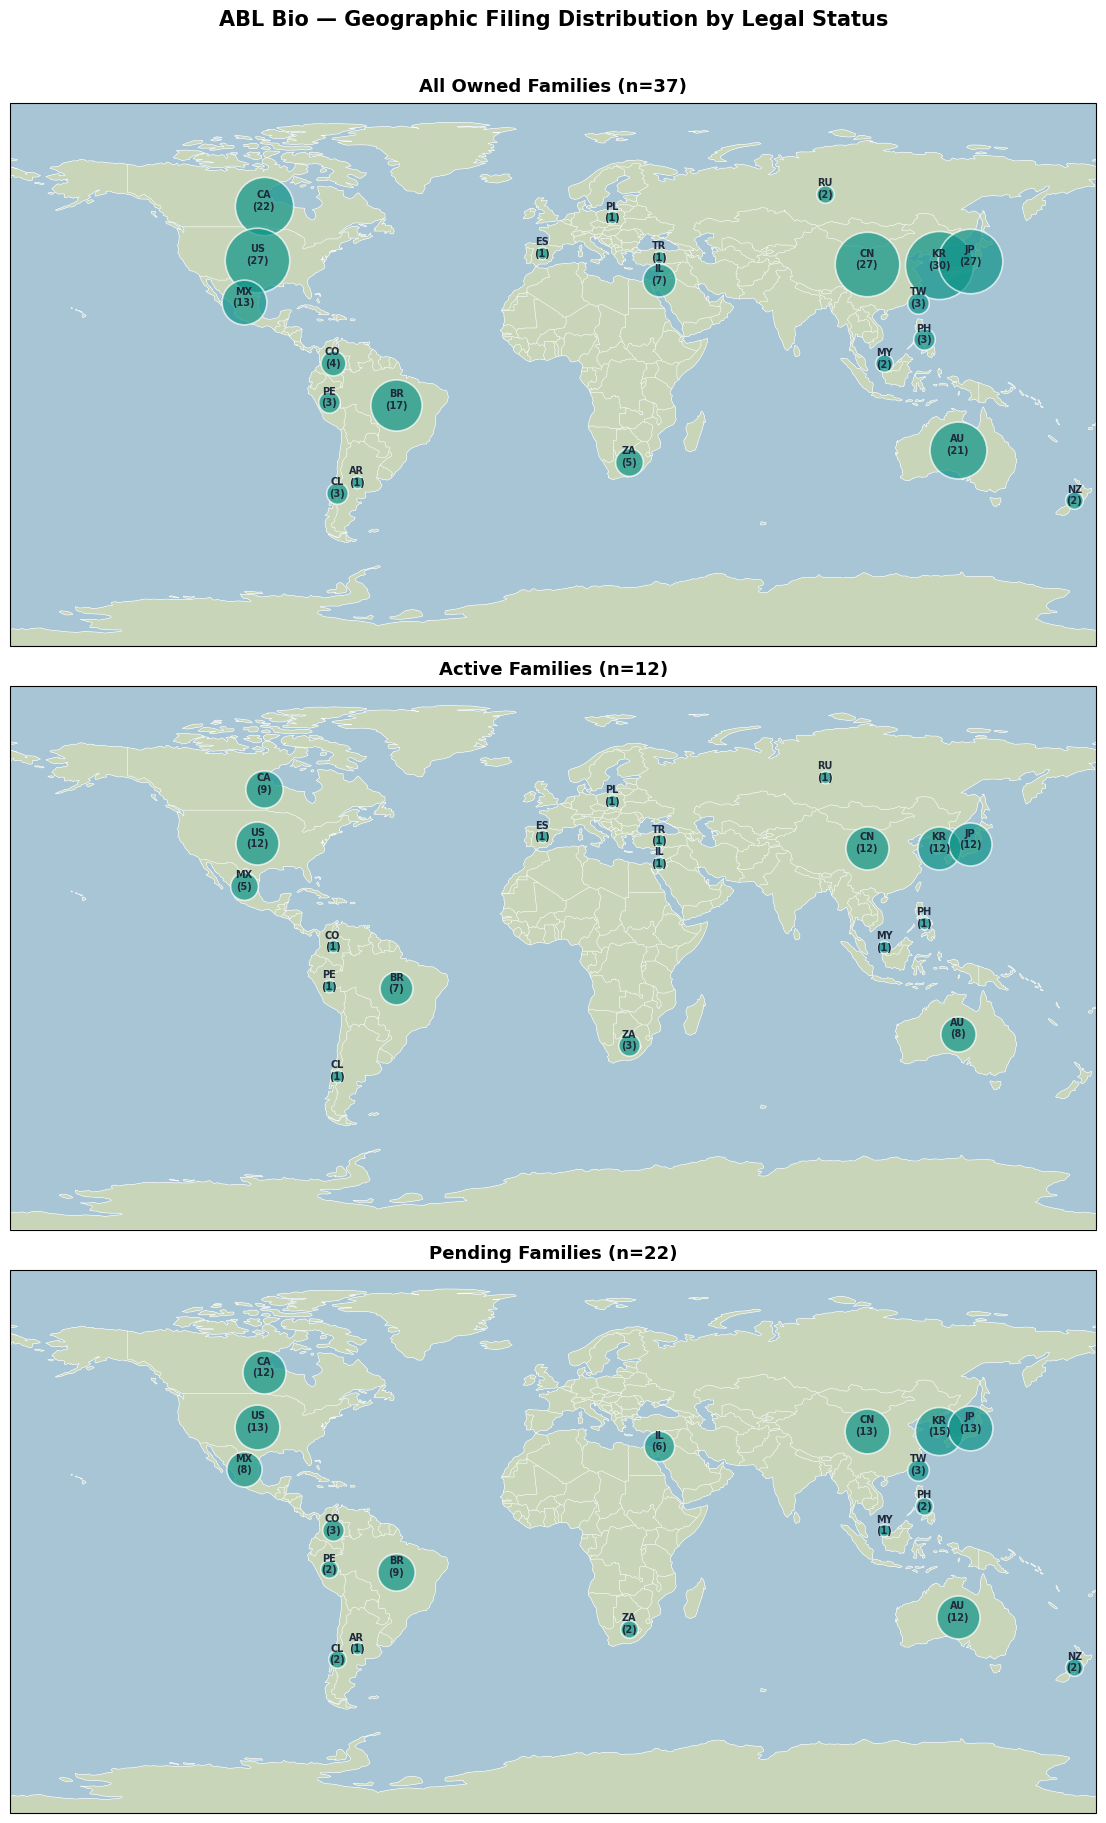

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def make_map(ax, df, title):
    jur_long = df['Extended Family Member Jurisdictions'].str.split(';;').explode().str.strip()
    juris_counts = jur_long.value_counts().reset_index()
    juris_counts.columns = ['Jurisdiction', 'Count']
    juris_counts = juris_counts[~juris_counts['Jurisdiction'].isin(['WO', 'EA', 'EP'])]
    juris_counts['ISO3'] = juris_counts['Jurisdiction'].map(juris_to_iso3)
    juris_counts = juris_counts.dropna(subset=['ISO3'])

    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#C8D5B9')      # greenish land
    ax.add_feature(cfeature.OCEAN, facecolor='#A8C5D6')     # blue ocean
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='white')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='white')

    world_merged = world.merge(juris_counts, left_on='ISO_A3', right_on='ISO3', how='left')
    world_merged['centroid'] = world_merged.geometry.centroid

    for _, row in world_merged.dropna(subset=['Count']).iterrows():
        x, y = get_coords(row)
        size = row['Count'] * 80
        # calculate offset based on bubble radius
        radius_deg = (size ** 0.1) * 0.1  # approximate degrees offset
        ax.scatter(x, y, s=size,
               color='#0D9488', alpha=0.7, zorder=5,
               edgecolors='white', linewidth=1.2,
               transform=ccrs.PlateCarree())
        ax.text(x, y + radius_deg - 1.5,
            f"{row['Jurisdiction']}\n({int(row['Count'])})",
            ha='center', fontsize=7, fontweight='bold',
            color='#1E293B', zorder=6,
            transform=ccrs.PlateCarree())

    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)

active = own_abl[own_abl['Legal Status'] == 'ACTIVE']
pending = own_abl[own_abl['Legal Status'] == 'PENDING']

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18),
                                     subplot_kw={'projection': ccrs.PlateCarree()})
make_map(ax1, own_abl, f"All Owned Families (n={len(own_abl)})")
make_map(ax2, active,  f"Active Families (n={len(active)})")
make_map(ax3, pending, f"Pending Families (n={len(pending)})")

fig.suptitle("ABL Bio — Geographic Filing Distribution by Legal Status",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Portfolio Structure 

Since there is 37 families, will manually annotate what each patent is for

In [155]:
print(own_abl.columns)

Index(['#', 'Jurisdiction', 'Kind', 'Display Key', 'Lens ID',
       'Publication Date', 'Publication Year', 'Application Number',
       'Application Date', 'Priority Numbers', 'Earliest Priority Date',
       'Title', 'Abstract', 'Applicants', 'Inventors', 'Owners', 'URL',
       'Document Type', 'Has Full Text', 'Cites Patent Count',
       'Cited by Patent Count', 'Simple Family Size', 'Simple Family Members',
       'Simple Family Member Jurisdictions', 'Extended Family Size',
       'Extended Family Members', 'Extended Family Member Jurisdictions',
       'Sequence Count', 'CPC Classifications', 'IPCR Classifications',
       'US Classifications', 'NPL Citation Count',
       'NPL Resolved Citation Count', 'NPL Resolved Lens ID(s)',
       'NPL Resolved External ID(s)', 'NPL Citations', 'Legal Status', 'Year',
       'has_us', 'has_ep', 'has_cn', 'has_jp', 'has_wo', 'jurisdiction_list'],
      dtype='object')


In [157]:
for i, row in own_abl.iterrows():
    print(f"\n--- Family {i+1} ---")
    print(row['Legal Status'])
    print("Title:")
    print(row['Title'])
    print("\nLens ID:")
    print(row['Lens ID'])
    print("\nCPC:")
    print(row['CPC Classifications'])


--- Family 1 ---
PENDING
Title:
ANTIBODIES FOR TREATING ALPHA-SYNUCLEINOPATHIES

Lens ID:
141-040-150-695-864

CPC:
C07K16/18;;C07K2317/24;;C07K16/2863;;A61P25/00;;A61K2039/505;;C07K2317/31;;A61P25/16;;C07K16/18;;C07K2317/24;;C07K2317/31;;C07K16/2863;;C07K2317/622;;C07K2317/92;;C07K16/18;;A61K2039/505;;C07K16/2863;;C07K2317/24;;C07K2317/31;;C07K2317/35;;C07K2317/565;;C07K2317/567;;C07K2317/622;;C07K2317/92;;A61P25/16;;C07K16/18;;C07K16/2863;;A61P25/00;;C07K2317/31;;C07K2317/35;;C07K2317/24;;C07K2317/92;;C07K2317/622;;C07K2317/565;;C07K2317/567;;A61K2039/505;;C07K16/18;;C07K16/2863;;A61P25/16;;A61K2039/505;;C07K2317/24;;C07K2317/92;;C07K2317/567;;C07K2317/622;;C07K2317/31;;C07K2317/35;;C07K2317/565

--- Family 2 ---
ACTIVE
Title:
ANTI-4-1BB ANTIBODY AND USE THEREOF

Lens ID:
084-986-690-232-010

CPC:
A61P35/00;;C07K2317/64;;C07K2317/622;;C07K16/2827;;C07K16/2878;;C07K2317/31;;C07K2317/24;;C07K2317/34;;C07K2317/92;;C07K2317/21;;C07K2317/75;;A61K2039/505;;A61K2039/505;;A61P35/00;;C07K16/

#### **The distribution looks like:**
<u>1) Purely Antibody Composition Patents:</u> (n=11)
- Families 1, 2, 6, 8, 10, 11, 12, 15, 22, 27, 31,
- Dominant CPC of C07K16/* (Immunoglobulins, e.g., monoclonal or polyclonal antibodies)
- For DLL4, 4-1BB, BCMA, alpha-synuclein, B7-H3, ROR1, CLL-1 

<u>2) Bi-specific Antibody Composition Patents:</u> (n=16)
- Families 3, 5, 7, 13, 14, 23, 24, 25, 26, 17, 18, 19, 20, 29, 30, 35
- For DLL4/VEGF, Alpha-SYN/IGF1R, PD-L1/LAG3, B7-H4/4-1BB, BCMA/4-1BB, TIGIT/4-1BB, LILRB4/4-1BB, HER2/4-1BB, EGFR/4-1BB, ROR1/4-1BB, ROR1/B7-H3, PD-L1/B7-H3, or Claudin 18.2/4-1BB

<u>3) ADC Composition Patents (Conjugate):</u> (n=3)
- Families 9 (Discontinued), 16, 28 (Discontinued), 32 (Discontinued), 33, 34
- Family 9 is **Payload-centric** patent: Cyclopropabenzindole (CBI) cytotocix payload linked to a galactose trigger moiety (breadth in antibody, target)
- Family 16 is **Full ADC** composition patent: Antibody-drug conjugates targeting ROR1, including active metabolites and pharmaceutical compositions for treatment of ROR1-overexpressing cancers
- Family 28 is a **Conjugated Linker** patent: Conjugating any drug to the N-terminal α-amine of any antibody via a linker with a reactive aldehyde (breadth in antibody, payload, target)
- Family 32 is **Full ADC** composition patent: Sequence-defined anti-ROR1 antibody conjugated via cleavable glucuronide/peptide linker architectures, including site-specific conjugation and branched dual-payload designs
- Family 33 is **Full ADC** composition patent: ROR1/B7-H3 bispecific antibody conjugated via cleavable glucuronide and peptide-based linker architectures, including site-specific C-terminal engineering and branched multi-payload designs
- Family 34 is **Full ADC** composition patent: Similar to above (Family 33) but with a monospecific platform, using anti-B7-H3 antibody


<u> 4) Clinical Filing:</u> (n=3)
- Family 21, 36, 37
- Family 21, with title "A method of treating a solid tumor" -> Summary is treating solid tumors using a CLDN18.2 bispecific antibody, with specified dosing ranges, schedules, routes, and patient populations (tumor types, advanced/metastatic setting)
- Family 36, with title "Combination of anti-claudin 18.2/anti-4-1bb antibodies and second therapeutic agent in treatment of cancer" -> Summary is use of a CLDN18.2/4-1BB bispecific antibody in combination with chemotherapeutic agents and/or immune checkpoint inhibitors (e.g., fluoropyrimidines, platinum agents, PD-1/PD-L1 antibodies), with specified dosing ranges, schedules, routes, and patient populations (tumor types, gastric cancer)
- Family 37, with title "Methods of treating cancer by administering anti-pd-l1/anti-4-1bb bispecific antibodies" -> Summary is treating advanced or metastatic solid tumors using a PD-L1/4-1BB bispecific antibody, with specified dosing ranges, schedules, route (IV), and patient populations (previously treated, relapsed, refractory cancers)


<u>5) CMC Patent:</u> (n=1)
- Family 4, with title "Method for Purifying Biologically Active Peptide by Using Protein A Affinity Chromatography"
- Summary is improved purification process for Fc-containing biologics using differential Protein A binding based on VH3 domain number
    - Wild-type protein A binds to Fc region of IgG (primary) as well as VH3 family variable domain (secondary). They determined that Protein A binding strength increases with more VH3 domains in the molecule
    - So instead of mutating Fc to artifically change affinity, use stepwise elution that will start with mild pH and then decrease -> molecules with weaker Protein A affinity elute first, followed by stronger binders at lower pH. This enables separation of highly similar antibody species


**Family 29 and 24 are relevant for NEOK001 or ABL-206**

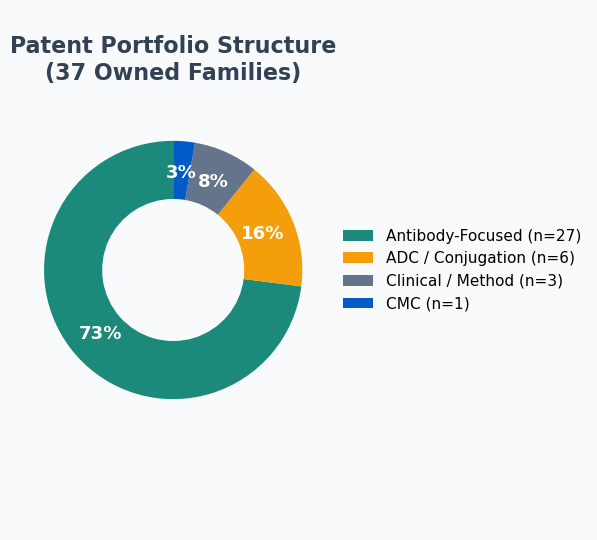

In [3]:
import matplotlib.pyplot as plt

# Data
labels = [
    "Antibody-Focused (n=27)",
    "ADC / Conjugation (n=6)",
    "Clinical / Method (n=3)",
    "CMC (n=1)"
]

sizes = [27, 6, 3, 1]

# Colors
colors = [
    "#1B8A7A",   # dark navy (core)
    "#F59E0B",   # orange (ADC)
    "#64748B",   # slate (clinical)
    "#005BC9"    # blue (CMC)
]


fig, ax = plt.subplots(figsize=(6,5.5))
#background color
bg_color = "#f8fafc"
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width':0.45},
    textprops={'color': 'white',
               'weight': 'bold',
               'fontsize': 13}
)

ax.set_title(
    "Patent Portfolio Structure\n(37 Owned Families)",
    fontsize=16,
    weight='bold',
    color="#334155",
    y=0.85
)

# Equal aspect ratio to make it circular
ax.axis('equal')

# legend
ax.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

# Key Inventors

Inventors of current portfolio (owner dataset)
- Looking into enforceable IP



In [7]:
own_abl['Inventors'].head()

0    AHN JINHYUNG;;AN SUNGWON;;KIM DONGIN;;SUNG EUN...
1    PARK EUNYOUNG;;LEE YANGSOON;;CHUNG HYEJIN;;JUN...
2    PARK EUNYOUNG;;LEE YANGSOON;;JUNG UIJUNG;;KIM ...
3    SONG DAEHAE;;PAK YOUNGDON;;JUNG JINWON;;HONG J...
4    AN SUNGWON;;AHN JINHYUNG;;SUNG BYUNGJE;;KIM DO...
Name: Inventors, dtype: object

In [8]:
own_inv = (
    own_abl
    .assign(Inventors=own_abl['Inventors'].str.split(';;'))
    .explode('Inventors')
)

own_inv['Inventors'] = own_inv['Inventors'].str.strip()

owner_counts = own_inv['Inventors'].value_counts()

owner_counts.head(10)

Inventors
JUNG JINWON      16
LEE YANGSOON     16
SUNG BYUNGJE     15
KIM JUHEE        14
PARK KYUNGJIN    13
PAK YOUNGDON     12
KIM YEUNJU       12
AHN JINHYUNG     12
YEOM DONGHOON    11
EOM JAEHYUN      11
Name: count, dtype: int64

Results suggest:
- Have about ~4 core inventors, that each seem to be appearing in ~40-50% of ABL Bio's owned simple families

Due the time and purpose of this case study, I will be looking into patents of just the top 5 inventors for each list
- JUNG JINWON
- LEE YANGSOON
- SUNG BYUNGJE
- KIM JUHEE
- PARK KYUNGJIN


So inputting into Lens.org:

(inventor.name:"JUNG JINWON" OR 
inventor.name:"LEE YANGSOON" OR 
inventor.name:"SUNG BYUNGJE" OR  
inventor.name:"KIM JUHEE" OR
inventor.name:"PARK KYUNGJIN")  
AND NOT (applicant.name:"ABL Bio"  
OR applicant.name:"ABLBIO")

But also to limit mis-identified inventors (due to same name), will try narrow it down to:  
AND (class_cpc.symbol:C07K16/*  
OR class_cpc.symbol:C07K2317/*  
OR class_cpc.symbol:A61K39/*  
OR class_cpc.symbol:A61K47/*)  

- C07K16/* → antibodies
- C07K2317/* → conjugates involving peptides/antibodies
- A61K39/* → medicinal antibodies
- A61K47/* → formulations & carriers (relevant for ADC linkers)

This will result in 10 simple families
- So 10 ADC-class patents, that involve ABL Bio’s core inventors but are not currently associated with ABL Bio as either applicant or owner
- Saved this as `inventor-no-abl.csv`

In [9]:
inv_ext = pd.read_csv("../data/raw/inventor-no-abl.csv")

print(inv_ext['Legal Status'].value_counts(),"\n")
print(inv_ext['Applicants'].value_counts().head(10))


Legal Status
PENDING    8
ACTIVE     2
Name: count, dtype: int64 

Applicants
YUHAN CORP                                                                                                                                                                                                                                                                                                                                                                                                                   3
TSD LIFE SCIENCES CO LTD                                                                                                                                                                                                                                                                                                                                                                                                     1
PARK YUN HEE;;SONG HO YOUNG;;RYU HYUN MIN;;KIM SUNG MIN;;BAEK JU YUEL;;OH JI HYE;;HAN NARA;;

---

# ABL Bio's Bi-specific Antibody Platforms:
- Grabody-T
- Grabody-B
- siRNA x Grabody-B
- ADC
- Bs ADC
- Dual payload Bs ADC


# Assets that are Licensed Out